# Customer Analytics — Deep EDA & Business Insights

**Role context:** Data Scientist at a Fintech/E-commerce company facing three growth problems:

1. **Rising CAC** (Cost Per Acquisition)
2. **High churn concentrated among valuable customers**
3. **Retention campaigns are mass-marketed** — sent to every customer regardless of risk or value, which wastes budget on customers who would stay (or leave) regardless, and over-treats/spams the rest, hurting brand experience

**Project goal:** identify the **top 20% priority customers** for intervention, to maximize retention rate and marketing-budget ROI.

This notebook is the analysis layer that grounds that goal in data — customer segmentation, value concentration, and operational patterns — before any model is built. It maps directly onto the "Data Analysis & Insights" side of the work: *analyze large datasets to identify trends, patterns, and opportunities; deliver insights that support customer segmentation, product performance, and operational efficiency.*

The propensity model that acts on these insights, and the campaign simulation that ties it back to ROI, live in [`02_propensity_targeting_campaign.ipynb`](02_propensity_targeting_campaign.ipynb). The model's methodology is documented in [`../docs/model_card_churn.md`](../docs/model_card_churn.md).

**Data:** `data/customers.csv` (signup date, observed lifetime) and `data/transactions.csv` (date, amount) — single-product transactional data, continuously growing via the project's Airflow simulation pipeline (see main [`README.md`](../README.md)).


In [1]:
%matplotlib inline
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from src.feature_engineering import build_churn_labels

plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

customers = pd.read_csv("../data/customers.csv", index_col=0)
transactions = pd.read_csv("../data/transactions.csv", index_col=0)
customers["signup_date"] = pd.to_datetime(customers["signup_date"])
transactions["transaction_date"] = pd.to_datetime(transactions["transaction_date"])

print(f"Customers:        {len(customers):,}")
print(f"Transactions:     {len(transactions):,}")
print(f"Date range:       {transactions['transaction_date'].min().date()} -> {transactions['transaction_date'].max().date()}")
print(f"Total revenue:    ${transactions['amount'].sum():,.0f}")


Customers:        4,533
Transactions:     72,238
Date range:       2025-01-03 -> 2026-07-11
Total revenue:    $4,219,392


## 1. Data quality & overview

Same rigor the production pipeline enforces at load time (`src/schemas.py` validates every raw row against a Pydantic schema) — checked here descriptively before any aggregation.

In [2]:
quality = pd.DataFrame({
    "customers": [customers.isna().sum().sum(), customers.duplicated().sum(), customers["customer_id"].duplicated().sum()],
    "transactions": [transactions.isna().sum().sum(), transactions.duplicated().sum(), np.nan],
}, index=["null_cells", "duplicate_rows", "duplicate_customer_ids"])
display(quality)

txns_per_customer = transactions.groupby("customer_id").size()
customers_without_txns = customers.loc[~customers["customer_id"].isin(transactions["customer_id"])]
print(f"Customers with zero recorded transactions: {len(customers_without_txns):,} ({len(customers_without_txns)/len(customers):.1%} of base)")
print(f"Transactions per customer — mean: {txns_per_customer.mean():.1f}, median: {txns_per_customer.median():.0f}, "
      f"p95: {txns_per_customer.quantile(0.95):.0f}, max: {txns_per_customer.max():.0f}")
print(f"Transaction amount — mean: ${transactions['amount'].mean():.2f}, median: ${transactions['amount'].median():.2f}, "
      f"p95: ${transactions['amount'].quantile(0.95):.2f}")


,customers,transactions
null_cells,0,0.00
duplicate_rows,0,0.00
duplicate_customer_ids,0,NaN


Customers with zero recorded transactions: 1,193 (26.3% of base)
Transactions per customer — mean: 21.6, median: 13, p95: 71, max: 233
Transaction amount — mean: $58.41, median: $41.01, p95: $171.69


## 2. Growth & acquisition proxy (Challenge #1 — rising CAC)

We don't have marketing spend data, so a true CAC figure can't be computed here — noted explicitly rather than fabricated. What the transaction data *can* show is the acquisition-efficiency proxy that matters most for the CAC conversation: **is each new cohort of customers actually monetizing**, or is the business acquiring more customers for flat/declining early revenue?

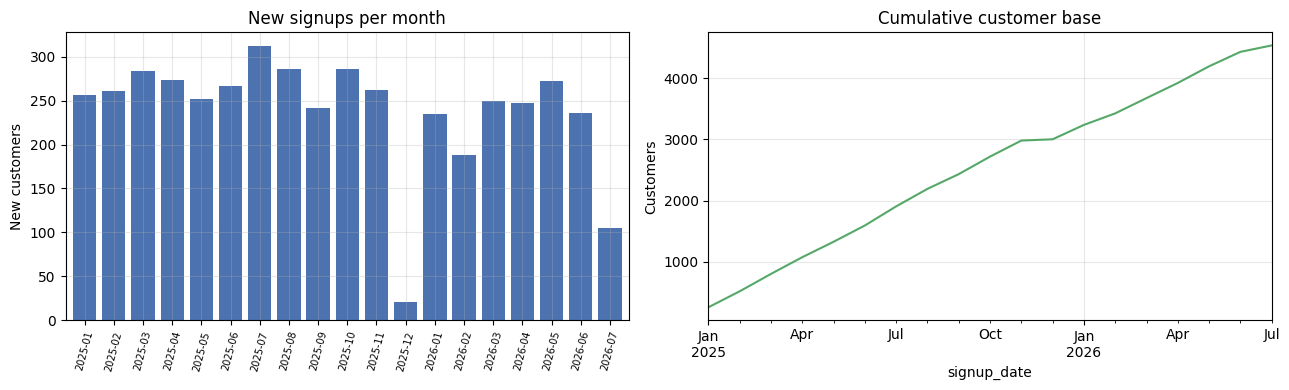

In [3]:
signups_by_month = customers.set_index("signup_date").resample("MS").size()
cumulative_customers = signups_by_month.cumsum()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
signups_by_month.plot(ax=axes[0], kind="bar", color="#4C72B0", width=0.8)
axes[0].set_title("New signups per month")
axes[0].set_xlabel("")
axes[0].set_ylabel("New customers")
axes[0].set_xticklabels([d.strftime("%Y-%m") for d in signups_by_month.index], rotation=75, fontsize=7)

cumulative_customers.plot(ax=axes[1], color="#55A868")
axes[1].set_title("Cumulative customer base")
axes[1].set_ylabel("Customers")
plt.tight_layout()
plt.show()


Excluded 3 recent cohort(s) with an incomplete 90-day observation window.


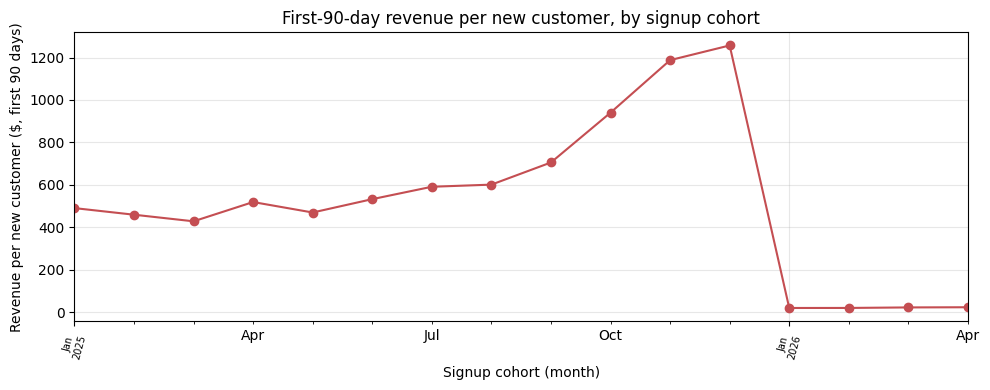

Cohort first-90-day revenue/customer — earliest 3 cohorts avg: $458.91, most recent 3 cohorts avg: $21.22


In [4]:
# Acquisition-efficiency proxy: first-90-day revenue per customer, by signup cohort month
max_date = transactions["transaction_date"].max()
customers["cohort"] = customers["signup_date"].dt.to_period("M")
txn_c = transactions.merge(customers[["customer_id", "signup_date", "cohort"]], on="customer_id")
txn_c["days_since_signup"] = (txn_c["transaction_date"] - txn_c["signup_date"]).dt.days
first_90d = txn_c[(txn_c["days_since_signup"] >= 0) & (txn_c["days_since_signup"] <= 90)]

cohort_rev = first_90d.groupby("cohort")["amount"].sum()
cohort_size = customers.groupby("cohort")["customer_id"].size()
cohort_rev_per_customer = (cohort_rev / cohort_size).dropna().sort_index()

# Point-in-time discipline: a cohort that signed up within the last 90 days
# hasn't had its full window observed yet — including it would show an
# artificially low "revenue per customer" that reflects censoring, not a
# real acquisition-efficiency signal. Same discipline the model pipeline
# enforces on features (see src/feature_engineering.py), applied here to EDA.
complete_cutoff = (max_date - pd.Timedelta(days=90)).to_period("M")
n_censored_cohorts = (cohort_rev_per_customer.index > complete_cutoff).sum()
cohort_rev_per_customer = cohort_rev_per_customer[cohort_rev_per_customer.index <= complete_cutoff]
cohort_rev_per_customer.index = cohort_rev_per_customer.index.to_timestamp()
print(f"Excluded {n_censored_cohorts} recent cohort(s) with an incomplete 90-day observation window.")

fig, ax = plt.subplots(figsize=(10, 4))
cohort_rev_per_customer.plot(ax=ax, marker="o", color="#C44E52")
ax.set_title("First-90-day revenue per new customer, by signup cohort")
ax.set_ylabel("Revenue per new customer ($, first 90 days)")
ax.set_xlabel("Signup cohort (month)")
plt.xticks(rotation=75, fontsize=7)
plt.tight_layout()
plt.show()

print(f"Cohort first-90-day revenue/customer — earliest 3 cohorts avg: ${cohort_rev_per_customer.head(3).mean():.2f}, "
      f"most recent 3 cohorts avg: ${cohort_rev_per_customer.tail(3).mean():.2f}")


**Reading this for the CAC conversation:** if first-90-day revenue per new customer is flat or declining across recent cohorts while the customer base keeps growing, every dollar of acquisition spend is buying a *less* monetizable customer than before — which is exactly what makes rising CAC dangerous rather than just a cost-line problem. This chart is the number to pair with a real CAC figure once spend data is available; on its own it already tells you whether the growth is healthy growth.

## 3. Revenue & transaction trends

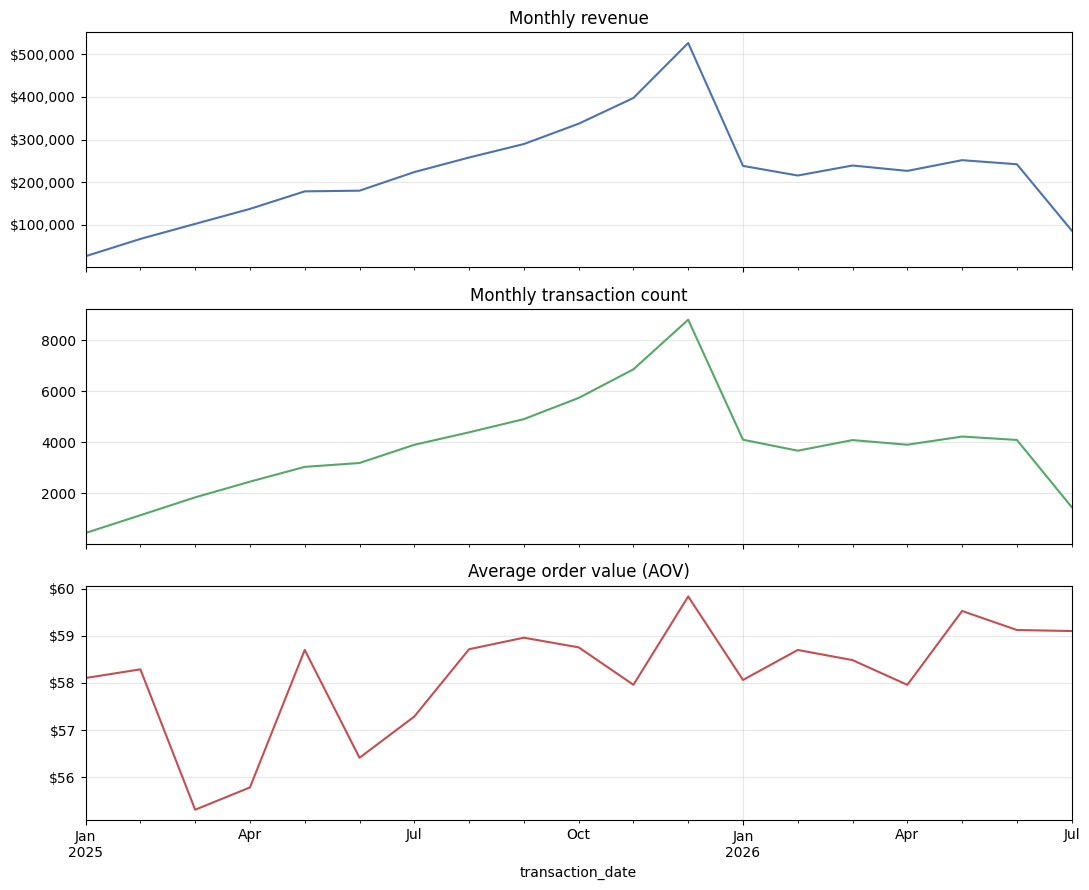

In [5]:
monthly = transactions.set_index("transaction_date").resample("MS").agg(
    revenue=("amount", "sum"), n_txns=("amount", "size")
)
monthly["aov"] = monthly["revenue"] / monthly["n_txns"]

fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)
monthly["revenue"].plot(ax=axes[0], color="#4C72B0")
axes[0].set_title("Monthly revenue")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

monthly["n_txns"].plot(ax=axes[1], color="#55A868")
axes[1].set_title("Monthly transaction count")

monthly["aov"].plot(ax=axes[2], color="#C44E52")
axes[2].set_title("Average order value (AOV)")
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.tight_layout()
plt.show()


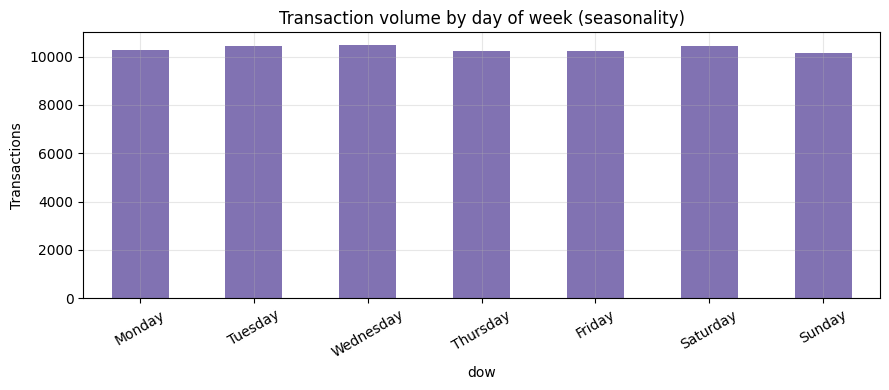

In [6]:
dow_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
by_dow = transactions.assign(dow=transactions["transaction_date"].dt.day_name()).groupby("dow").agg(
    n_txns=("amount", "size"), revenue=("amount", "sum")
).reindex(dow_order)

fig, ax = plt.subplots(figsize=(9, 4))
by_dow["n_txns"].plot(ax=ax, kind="bar", color="#8172B2")
ax.set_title("Transaction volume by day of week (seasonality)")
ax.set_ylabel("Transactions")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


## 4. Customer value concentration (Challenge #2 — "khách hàng giá trị")

Before targeting "valuable customers," it's worth putting a number on how concentrated value actually is. A Lorenz curve / Pareto view answers: *what share of customers generates what share of revenue?*

/var/folders/pp/ynfzr7yx2mz8y_75j6hfpwt80000gn/T/ipykernel_4895/1889033010.py:11: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  gini = 1 - 2 * np.trapz(cum_rev_share, cum_cust_share)


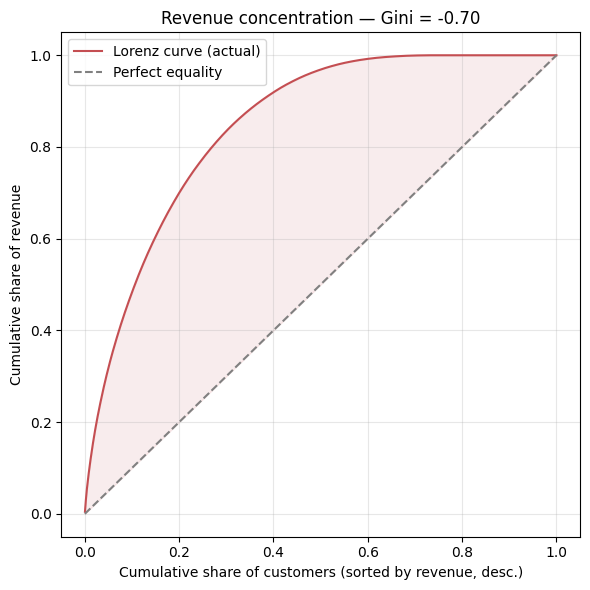

Top 10% of customers generate 48.3% of total revenue
Top 20% of customers generate 70.0% of total revenue
Top 50% of customers generate 96.9% of total revenue


In [7]:
cust_revenue = transactions.groupby("customer_id")["amount"].sum().reindex(customers["customer_id"]).fillna(0.0)
sorted_rev = cust_revenue.sort_values(ascending=False).values
cum_rev_share = np.cumsum(sorted_rev) / sorted_rev.sum()
cum_cust_share = np.arange(1, len(sorted_rev) + 1) / len(sorted_rev)

def revenue_share_at(top_pct):
    k = int(len(sorted_rev) * top_pct)
    return sorted_rev[:k].sum() / sorted_rev.sum()

# Gini coefficient
gini = 1 - 2 * np.trapz(cum_rev_share, cum_cust_share)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(cum_cust_share, cum_rev_share, color="#C44E52", label="Lorenz curve (actual)")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfect equality")
ax.fill_between(cum_cust_share, cum_rev_share, cum_cust_share, alpha=0.1, color="#C44E52")
ax.set_xlabel("Cumulative share of customers (sorted by revenue, desc.)")
ax.set_ylabel("Cumulative share of revenue")
ax.set_title(f"Revenue concentration — Gini = {gini:.2f}")
ax.legend()
plt.tight_layout()
plt.show()

for p in [0.10, 0.20, 0.50]:
    print(f"Top {p:.0%} of customers generate {revenue_share_at(p):.1%} of total revenue")


This is the empirical basis for "valuable customers" in the business framing: value is concentrated, not evenly spread — so a churn-prevention program that treats every customer identically is, by construction, misallocating effort relative to where the revenue actually sits.

## 5. RFM segmentation deep-dive

Quantile-based Recency/Frequency/Monetary scoring, mapped to named segments — the standard customer-segmentation lens, extended here with revenue-share-by-segment so segment size and segment *value* aren't conflated.

In [8]:
snapshot_date = transactions["transaction_date"].max() + pd.Timedelta(days=1)

rfm = transactions.groupby("customer_id").agg(
    recency=("transaction_date", lambda s: (snapshot_date - s.max()).days),
    frequency=("amount", "size"),
    monetary=("amount", "sum"),
)
rfm = rfm.reindex(customers["customer_id"]).fillna({"recency": 999, "frequency": 0, "monetary": 0.0})

rfm["R_score"] = pd.qcut(rfm["recency"].rank(method="first"), 4, labels=[4, 3, 2, 1]).astype(int)   # lower recency = better = higher score
rfm["F_score"] = pd.qcut(rfm["frequency"].rank(method="first"), 4, labels=[1, 2, 3, 4]).astype(int)
rfm["M_score"] = pd.qcut(rfm["monetary"].rank(method="first"), 4, labels=[1, 2, 3, 4]).astype(int)
rfm["RFM_sum"] = rfm[["R_score", "F_score", "M_score"]].sum(axis=1)

def segment(row):
    r, f, m = row["R_score"], row["F_score"], row["M_score"]
    if r >= 3 and f >= 3 and m >= 3:
        return "Champions"
    if r >= 3 and f >= 2:
        return "Loyal Customers"
    if r >= 3 and f <= 2:
        return "Promising / New"
    if r == 2 and f >= 2:
        return "At Risk"
    if r <= 2 and f >= 3 and m >= 3:
        return "At Risk (High Value)"
    if r <= 2 and f <= 2:
        return "Hibernating"
    return "Other"

rfm["segment"] = rfm.apply(segment, axis=1)

segment_profile = rfm.groupby("segment").agg(
    n_customers=("segment", "size"), total_revenue=("monetary", "sum"),
    avg_recency=("recency", "mean"), avg_frequency=("frequency", "mean"),
).sort_values("total_revenue", ascending=False)
segment_profile["pct_customers"] = segment_profile["n_customers"] / segment_profile["n_customers"].sum()
segment_profile["pct_revenue"] = segment_profile["total_revenue"] / segment_profile["total_revenue"].sum()
display(segment_profile.style.format({"pct_customers": "{:.1%}", "pct_revenue": "{:.1%}", "total_revenue": "${:,.0f}"}))


,n_customers,total_revenue,avg_recency,avg_frequency,pct_customers,pct_revenue
segment,,,,,,
Champions,1878,"$3,805,538",17.174121,34.536741,41.4%,90.2%
At Risk,1073,"$342,503",167.304753,5.381174,23.7%,8.1%
Loyal Customers,389,"$71,351",26.825193,4.123393,8.6%,1.7%
Hibernating,1193,$0,999.000000,0.000000,26.3%,0.0%


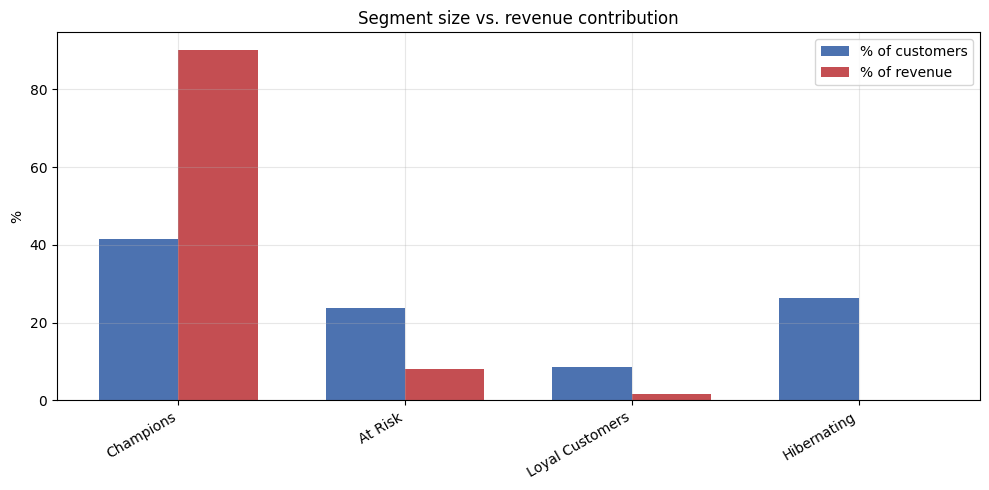

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
order = segment_profile.index
x = np.arange(len(order))
width = 0.35
ax.bar(x - width/2, segment_profile["pct_customers"] * 100, width, label="% of customers", color="#4C72B0")
ax.bar(x + width/2, segment_profile["pct_revenue"] * 100, width, label="% of revenue", color="#C44E52")
ax.set_xticks(x)
ax.set_xticklabels(order, rotation=30, ha="right")
ax.set_ylabel("%")
ax.set_title("Segment size vs. revenue contribution")
ax.legend()
plt.tight_layout()
plt.show()


**The segment that matters most for challenge #2** is `At Risk (High Value)`: customers with strong historical frequency and monetary scores whose recency has slipped. They are simultaneously valuable (high `M_score`/`F_score`) and at risk (low `R_score`) — exactly the customers a mass-marketing program is most likely to either miss (buried among low-value "At Risk" customers) or reach too late.

## 6. Mass-marketing waste quantification (Challenge #3)

Directly quantifying the complaint in the business framing: *"Gửi voucher cho người chắc chắn đi hoặc người chắc chắn ở lại"* (sending vouchers to people who will leave or stay regardless). Using a forward-looking 30-day window (mirroring the churn model's label definition — see [`docs/model_card_churn.md`](../docs/model_card_churn.md)), we can classify the base into buckets a blanket campaign cannot distinguish between, but a targeted campaign can.

In [10]:
INACTIVITY_WINDOW = 30
label_snapshot = transactions["transaction_date"].max() - pd.Timedelta(days=INACTIVITY_WINDOW)
labels = build_churn_labels(transactions, label_snapshot, INACTIVITY_WINDOW).set_index("customer_id")

waste = rfm.join(labels, how="left")
waste["churn"] = waste["churn"].fillna(1).astype(int)  # customers with zero txns before snapshot: treat as already-churned/inactive

def waste_bucket(row):
    if row["segment"] == "Champions" and row["churn"] == 0:
        return "Sure stayer (Champion, retained anyway)"
    if row["segment"] == "Hibernating":
        return "Unlikely responder (long-inactive)"
    if "At Risk" in row["segment"]:
        return "Genuine intervention opportunity (At Risk)"
    return "Other / uncertain"

waste["bucket"] = waste.apply(waste_bucket, axis=1)
bucket_summary = waste.groupby("bucket").agg(n_customers=("bucket", "size"), revenue=("monetary", "sum"))
bucket_summary["pct_customers"] = bucket_summary["n_customers"] / bucket_summary["n_customers"].sum()
display(bucket_summary.sort_values("pct_customers", ascending=False).style.format(
    {"pct_customers": "{:.1%}", "revenue": "${:,.0f}"}
))

wasted_pct = bucket_summary.loc[bucket_summary.index.str.startswith(("Sure stayer", "Unlikely responder")), "pct_customers"].sum()
print(f"\nUnder mass marketing (contact 100% of the base), an estimated {wasted_pct:.1%} of "
      f"campaign contacts go to customers who would stay anyway or are very unlikely to respond — "
      f"budget spent with close to zero incremental effect, plus the over-treatment/spam cost to those customers.")


,n_customers,revenue,pct_customers
bucket,,,
"Sure stayer (Champion, retained anyway)",1513,"$3,366,415",33.4%
Unlikely responder (long-inactive),1193,$0,26.3%
Genuine intervention opportunity (At Risk),1073,"$342,503",23.7%
Other / uncertain,754,"$510,474",16.6%



Under mass marketing (contact 100% of the base), an estimated 59.7% of campaign contacts go to customers who would stay anyway or are very unlikely to respond — budget spent with close to zero incremental effect, plus the over-treatment/spam cost to those customers.


## 7. Value-tier performance (product-performance analysis)

> This dataset has no product/category dimension — a deliberate scope decision for this iteration (see `../README.md`). "Product performance" is reinterpreted here as **spend-tier performance**: the same analytical approach (which tier is growing, which is shrinking, which converts best) applied to value tiers instead of SKUs, using the fields the data actually has.

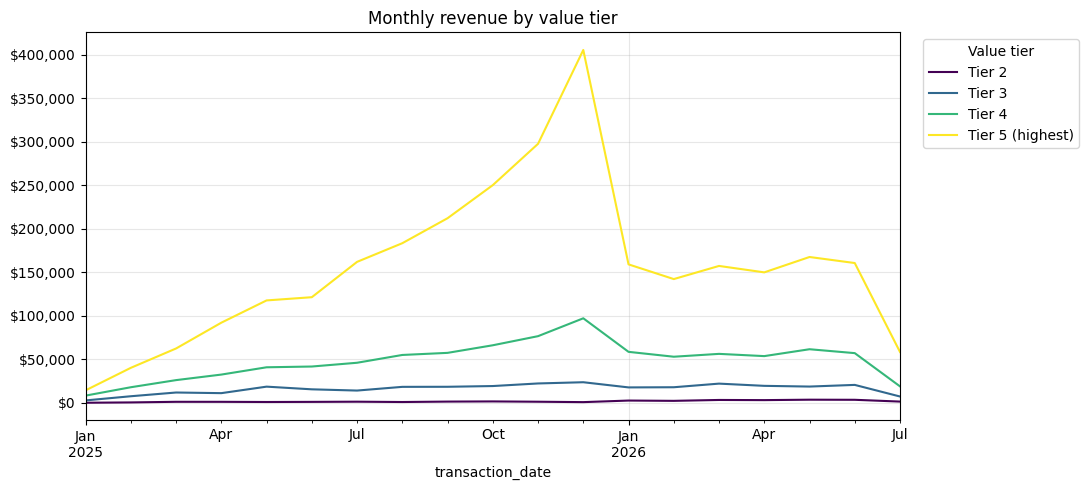

,n_customers,revenue,avg_order_value,revenue_per_customer,txns_per_customer
tier,,,,,
Tier 2,620,"$32,968",$32.87,$53,1.6
Tier 3,907,"$308,023",$44.76,$340,7.6
Tier 4,906,"$925,143",$51.77,"$1,021",19.7
Tier 5 (highest),907,"$2,953,258",$63.53,"$3,256",51.2


In [11]:
value_tiers = pd.qcut(cust_revenue.rank(method="first"), 5, labels=["Tier 1 (lowest)", "Tier 2", "Tier 3", "Tier 4", "Tier 5 (highest)"])
tier_df = pd.DataFrame({"customer_id": cust_revenue.index.to_numpy(), "tier": value_tiers.to_numpy(), "total_revenue": cust_revenue.to_numpy()})

tier_txns = transactions.merge(tier_df[["customer_id", "tier"]], on="customer_id")
tier_monthly = tier_txns.set_index("transaction_date").groupby([pd.Grouper(freq="MS"), "tier"], observed=True)["amount"].sum().unstack("tier")

fig, ax = plt.subplots(figsize=(11, 5))
tier_monthly.plot(ax=ax, colormap="viridis")
ax.set_title("Monthly revenue by value tier")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.legend(title="Value tier", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

tier_summary = tier_txns.groupby("tier", observed=True).agg(
    n_customers=("customer_id", "nunique"), n_txns=("amount", "size"),
    revenue=("amount", "sum"), avg_order_value=("amount", "mean"),
)
tier_summary["revenue_per_customer"] = tier_summary["revenue"] / tier_summary["n_customers"]
tier_summary["txns_per_customer"] = tier_summary["n_txns"] / tier_summary["n_customers"]
display(tier_summary[["n_customers", "revenue", "avg_order_value", "revenue_per_customer", "txns_per_customer"]].style.format(
    {"revenue": "${:,.0f}", "avg_order_value": "${:.2f}", "revenue_per_customer": "${:,.0f}", "txns_per_customer": "{:.1f}"}
))


## 8. Operational efficiency insights

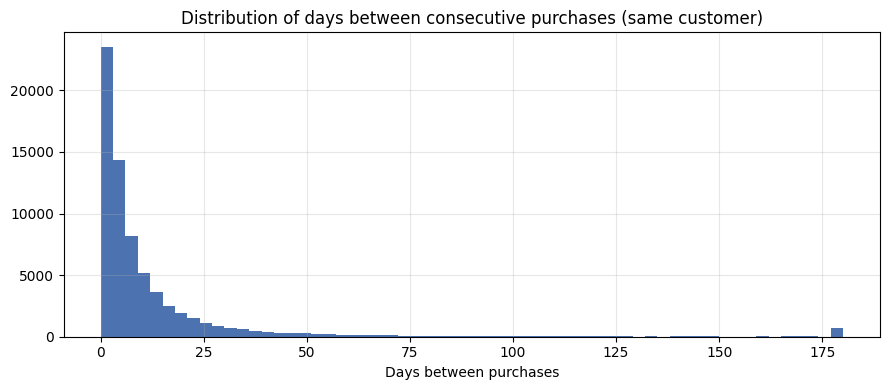

Purchase gap — median: 5 days, p90: 27 days, p99: 180 days
Same-day repeat purchases (gap = 0 days): 5,472 (7.94% of consecutive-purchase pairs) — worth a data-quality/fraud spot-check if this share is unexpectedly high.


In [12]:
# Purchase-gap outlier analysis: time between a customer's consecutive transactions
txn_sorted = transactions.sort_values(["customer_id", "transaction_date"])
gap_days = txn_sorted.groupby("customer_id")["transaction_date"].diff().dt.days.dropna()

fig, ax = plt.subplots(figsize=(9, 4))
gap_days.clip(upper=gap_days.quantile(0.99)).hist(ax=ax, bins=60, color="#4C72B0")
ax.set_title("Distribution of days between consecutive purchases (same customer)")
ax.set_xlabel("Days between purchases")
plt.tight_layout()
plt.show()

print(f"Purchase gap — median: {gap_days.median():.0f} days, p90: {gap_days.quantile(0.90):.0f} days, "
      f"p99: {gap_days.quantile(0.99):.0f} days")
print(f"Same-day repeat purchases (gap = 0 days): {(gap_days == 0).sum():,} "
      f"({(gap_days == 0).mean():.2%} of consecutive-purchase pairs) — worth a data-quality/fraud spot-check "
      f"if this share is unexpectedly high.")


**Reading these operationally:**
- Day-of-week volume (§3) tells staffing/ops when transaction-support load peaks — flat support capacity across a week with a clear weekday/weekend skew in volume is a mismatch worth flagging.
- The purchase-gap distribution's right tail is the reactivation-timing signal: customers who typically buy every ~30 days but are now past their p90 gap are the ones a "days-since-last-purchase" trigger should catch *before* they fully churn — the same recency feature the propensity model formalizes in the next notebook.
- Revenue concentration (§4) doubles as an operational **key-account risk**: a small number of customers hold a disproportionate share of revenue, so losing even one materially affects results — a different operational conversation than volume-based staffing, but the same underlying number.

## 9. Executive summary

| Business challenge | What the data shows | Where |
|---|---|---|
| **#1 Rising CAC** | First-90-day revenue per new customer is the acquisition-efficiency proxy in the absence of real spend data — flat/declining recent cohorts is the early-warning signal to pair with a future CAC figure. | §2 |
| **#2 Churn among valuable customers** | Revenue is concentrated (Gini computed in §4); the `At Risk (High Value)` RFM segment is exactly the group that is both revenue-significant and slipping — the highest-priority target for intervention. | §4, §5 |
| **#3 Wasteful mass marketing / over-treatment** | A meaningful share of the base falls into "sure stayer" or "unlikely responder" buckets that a blanket campaign cannot distinguish — quantified directly in §6. | §6 |

**This is the case for a targeting model.** Segmentation and value concentration tell us *who is worth protecting*; the waste analysis tells us *why mass marketing can't do it efficiently*. The next notebook, [`02_propensity_targeting_campaign.ipynb`](02_propensity_targeting_campaign.ipynb), builds the churn-propensity model, combines it with a customer-value proxy into a single priority score, and simulates the ROI of targeting only the top 20% instead of the whole base.